# Job Function Exploration
A non-profit organization wishes to analyze the career trajectory of program alumni pre and post fellowship.  One categorical variable of interest, job function, is missing from many records as it hasn't collected across all time.  They require a machine learning model capable of classifiying these unknown job functions given existing data.

This file will help assess the usefullness of relevent columns and identifying which cleaning steps need to be taken before a classification model can be trained.

While this analysis will focus primarily on assessing the performance of a simple TFIDF model trained on NLP data, EDA and cleaning will touch on additional categorical columns that may be valuable in developing a more complex classification model.

Data Cleaning files:
- 'scripts/clean_aff_data.py'
- 'notebooks/clean_aff_data.ipynb'
- 'outputs/visualizations/raw_data'
- 'outputs/visualizations/cleaned_data'

Classification with TFIDF:
- 'notebooks/job_function_classification.ipynb'
- 'outputs/visualizations/classification_tfidf'

# Setup

## Packages

In [32]:
# General packages
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

## Import Data
- A sample of the raw data, as well as the cleaned data, can be found within the data folder

In [2]:
# import data
aff = pd.read_csv("../data/full/job_affiliations.csv")

aff = aff.replace(r"^\s*$", pd.NA, regex=True)

In [3]:
aff.sample(200, random_state = 34).to_csv('../data/raw_data_sample.csv')

# EDA
- Job 'title' and 'role' are both free-response, NLP variables

- Job 'function' is categorical and filling in it's missing values is the ultimate goal of the analysis

- Job 'management_level' and 'role_level' are also categorical and may be helpful in creating a more sophisticated TFIDF model

In [4]:
aff.info()

<class 'pandas.DataFrame'>
RangeIndex: 109485 entries, 0 to 109484
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   affiliate_id_18   109485 non-null  str  
 1   function          90572 non-null   str  
 2   title             51280 non-null   str  
 3   role              46778 non-null   str  
 4   management_level  70720 non-null   str  
 5   role_level        29230 non-null   str  
dtypes: str(6)
memory usage: 5.0 MB


In [5]:
aff.head()

,affiliate_id_18,function,title,role,management_level,role_level
0,a0d3300000CSzeXAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN
1,a0d3300000CSzjSAAT,General Management,NaN,Special Associate to the President,NaN,NaN
2,a0d3300000CSzjUAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN
3,a0d3300000CSzo6AAD,Academics (Teaching & Learning),NaN,Talented and Gifted Teacher,NaN,NaN
4,a0d3300000CSzo7AAD,Academics (Teaching & Learning),NaN,Elementary Teacher,NaN,NaN


## Check Duplicates

In [6]:
# count duplicate records
complete_duplicates = aff.duplicated().sum()
print(f"{complete_duplicates} Complete Duplicates")

0 Complete Duplicates


## Missing Values
- The heatmap below illustrates what appears to be a complementary relationship between missing job roles and titles.

- Role level exists for only 27% of records and less than 1% of those records are missing a job function.

    - Integrating role level into our classification model will not improve performance.

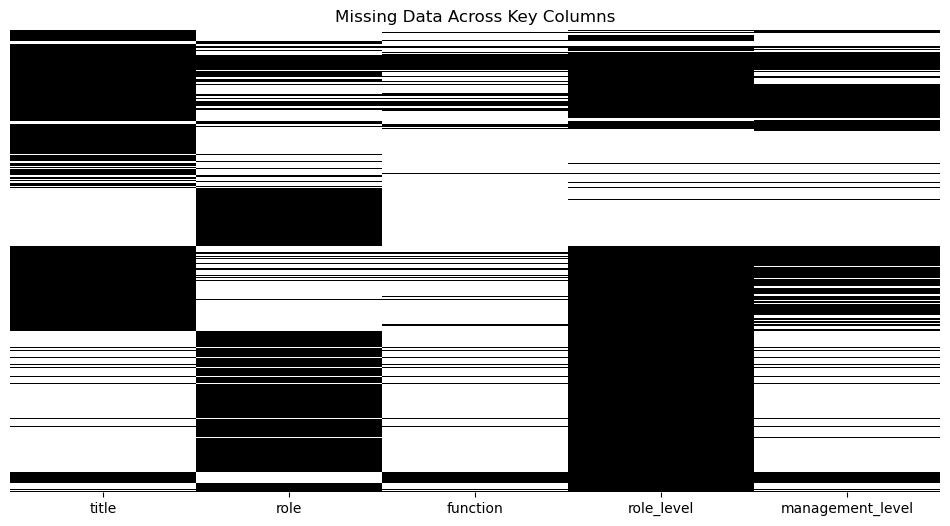

In [8]:
# missing value heatmap
needed_columns = ['title', 'role', 'function', 'role_level', 'management_level']

plt.figure(figsize=(12, 6))

sns.heatmap(
    aff[needed_columns].isnull(),
    cmap=ListedColormap(['white', 'black']),
    cbar=False,
    yticklabels=False
)
plt.title('Missing Data Across Key Columns')

plt.savefig(
    "../outputs/visualizations/raw_data/missing_values_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [9]:
# missing values in role and title
missing_role_perc = round(aff['role'].isna().mean()*100,0).astype(int)
missing_title_perc = round(aff['title'].isna().mean()*100,0).astype(int)
missing_role_level_perc = round(aff['role_level'].isna().mean()*100,0).astype(int)
missing_management_level_perc = round(aff['management_level'].isna().mean()*100,0).astype(int)

print(f"{missing_role_perc}% records missing role")
print(f"{missing_title_perc}% records missing title")
print(f"{missing_role_level_perc}% records missing role level")
print(f"{missing_management_level_perc}% records missing management level")

57% records missing role
53% records missing title
73% records missing role level
35% records missing management level


In [ ]:
role_level_not_na_function_na = round(aff[aff['role_level'].notna()]['function'].isna().mean()*100,3)
print(f"{role_level_not_na_function_na}% records with role level are missing function")

0.274% records with role level that are missing function


## Comparing Job Title and Role
- While only 1% of records have both a title and role, 11% are missing both title and role.

- A visual inspection of Titles and Roles hint that 'role' and 'title' have been used interchangably over time.

    - This can be validated by the fact that 81% of records with a title and role have identical responses.

- Job Title may be a suitable substitute for job role in instances where it's missing.


In [10]:
# filter for recrods MISSING both title and role
role_nan_mask = aff['role'].isna()
title_nan_mask = aff['title'].isna()

role_title_nan_pct = int(round(len(aff[role_nan_mask & title_nan_mask])*100/len(aff),0))
print(f'{role_title_nan_pct}% of records MISSING both title and role')

11% of records MISSING both title and role


In [11]:
# filter for recrods HAVING both title and role
has_role_mask = (aff['role'].notna()) & (aff['role'] != '')
has_title_mask = (aff['title'].notna()) & (aff['title'] != '')

role_title_nan_pct = int(round(len(aff[has_role_mask & has_title_mask])*100/len(aff),0))
print(f'{role_title_nan_pct}% of records HAVING both title and role')

1% of records HAVING both title and role


In [30]:
# comparing role and title
has_role_mask = (aff['role'].notna()) & (aff['role'] != '')
has_title_mask = (aff['title'].notna()) & (aff['title'] != '')

role_title_df = aff[has_role_mask & has_title_mask]
role_title_len = len(role_title_df)

role_title_match = role_title_df[role_title_df['role'] == role_title_df['title']]
role_title_match_len = len(role_title_match)

display(role_title_match[['role', 'title']])

print(f"For records with both role and title, {round((role_title_match_len*100)/role_title_len, 0)}% of job roles match job titles")

,role,title
239,7th Grade Social Studies,7th Grade Social Studies
243,Teacher in Residence,Teacher in Residence
244,Program and Volunteer Manager,Program and Volunteer Manager
252,Certified Teacher,Certified Teacher
263,Grade Level Chair / Department Chair / Teacher...,Grade Level Chair / Department Chair / Teacher...
...,...,...
109479,Executive Director,Executive Director
109480,Director of Talent,Director of Talent
109481,Project Director,Project Director
109482,Director of Research and Senior Program Office...,Director of Research and Senior Program Office...


For records with both role and title, 81.0% of job roles match job titles


In [31]:
# records where the role and title don't match
role_title_mismatch = role_title_df[role_title_df['role'] != role_title_df['title']]
display(role_title_mismatch[['role', 'title']])

,role,title
648,Graduate School Fellow,Education Pioneers Fellow
1010,"Teacher, 3rd grade self-contained","Teacher, 3rd Grade (House Team Coordinator)"
1018,Teacher Recruitment and Retention Team Member,House Team Coordinator
3363,Executive DIrector,Founding Executive Director of Achievement Net...
3636,Substitute Teacher,Special Education Assistant
...,...,...
104134,Consultant,Associate
104707,Director,Executive Director of Educators for Excellence...
104920,School Turnaround Group,Managing Director
105030,District Success Manager,School District Success Manager


### Investigating the Average Length of Natural Language Columns
- Role and Title, when they exist, are very short- haveing a median of just 3 terms.

- An LSTM or Transformer model would likely be overkill

- The use of a TFIDF is more appropriate for such short texts

In [52]:
# average nl lengths
role_term_count = aff[has_role_mask]['role'].fillna("").apply(lambda x: len(x.split()))
title_term_count = aff[has_title_mask]['title'].fillna("").apply(lambda x: len(x.split()))

print(f"Role has a median length of {role_term_count.median()}")
print(f"Title has a median length of {title_term_count.median()}")

Role has a median length of 3.0
Title has a median length of 3.0


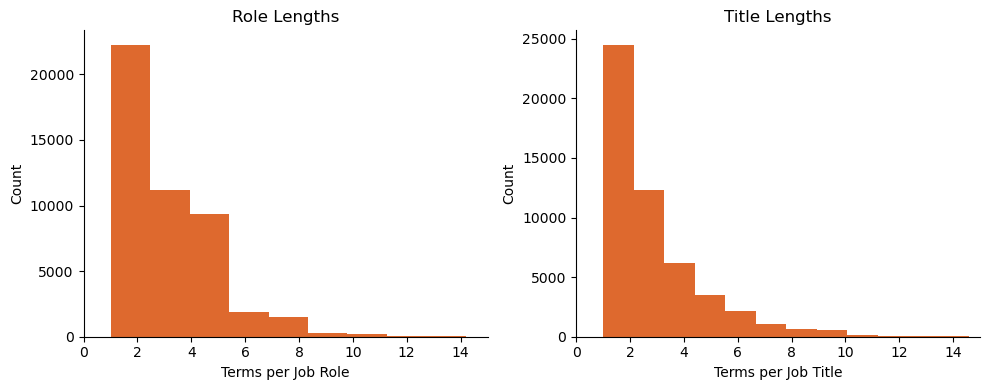

In [53]:
# visualizations
fig, axes = plt.subplots(1,2, figsize = (10,4))

axes[0].hist(role_term_count, bins=15, color = "#DE692E")
axes[0].set_xlim(0, 15)

axes[0].set_title("Role Lengths")
axes[0].set_xlabel("Terms per Job Role")
axes[0].set_ylabel("Count")

axes[1].hist(title_term_count, bins=15, color = '#DE692E')
axes[1].set_xlim(0, 15)

axes[1].set_title("Title Lengths")
axes[1].set_xlabel("Terms per Job Title")
axes[1].set_ylabel("Count")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    "../outputs/visualizations/raw_data/term_counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## Categorical Columns: function, management_level, and role_level
- Function, Role Level, and Management Level all contain rarely used classes and duplicate classes.

- There apears to be some overlap in job function which may negativly impact the performance of our model.

- This overlap is particularily eggregious in Managment Level.

### Job Functions

In [13]:
function_counts = aff["function"].value_counts().reset_index()
display(function_counts)

,function,count
0,Academics (Teaching & Learning),23084
1,Data / Analytics / Research,10418
2,Program and Project Management,8817
3,General Management,8566
4,Operations,5585
5,Academics (Teaching and Learning),4321
6,Consulting,3925
7,Marketing / Communications / External Relations,3671
8,School Leadership / Administration,3314
9,Finance / Budgeting / Accounting,2993


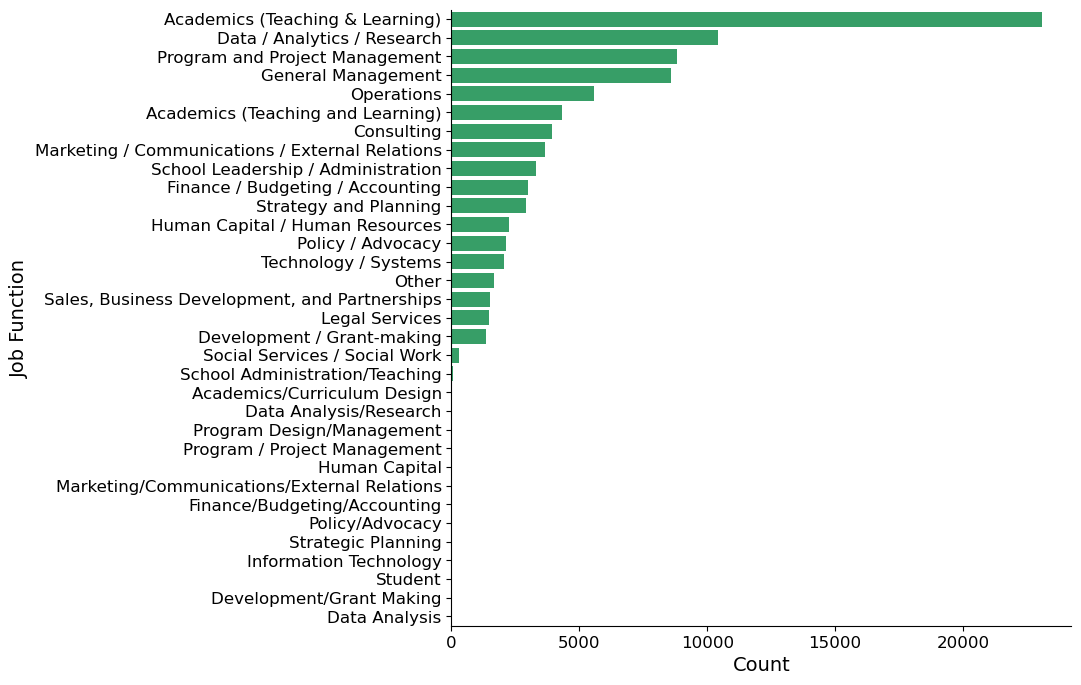

In [ ]:
# visualization
function_class_dist = aff['function'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='function', order=function_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Job Function", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../outputs/visualizations/raw_data/job_functions_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### Management Level

- A casual examination of Management Levels makes clear significant overlap between classes.

    - While "Manages Self/Projects" is distinct enough, it's concievable that job could fall within "Manages Others", "Manages a Group", "Manages Functions", "Manages Managers", and "Manages Organization".

    - In this state, Management Level is too ambiguous to provide clear insights on its own.

In [16]:
management_level_counts = aff["management_level"].value_counts().reset_index()
display(management_level_counts)

,management_level,count
0,Manages self/projects - 1,32482
1,Manages others - 2,15345
2,Manages self/projects,6097
3,Manages a group - 5,3758
4,Manages function(s) - 4,3549
5,Manages others,2586
6,Manages managers - 3,2275
7,Manages organization - 6,1919
8,Manages a group,1221
9,Manages function(s),835


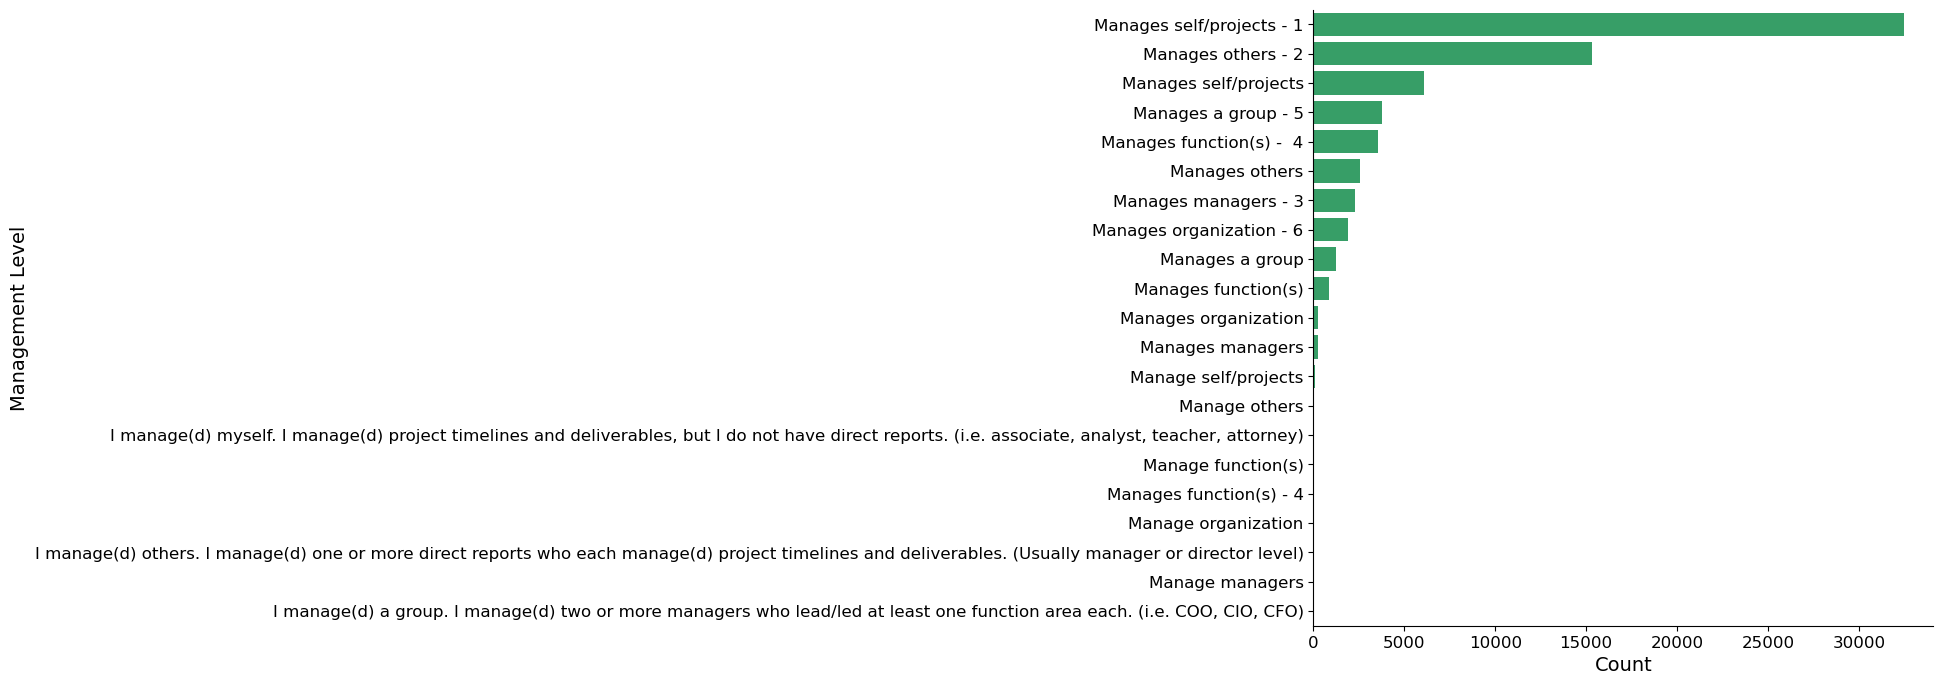

In [18]:
# visualization
management_class_dist = aff['management_level'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='management_level', order=management_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Management Level", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../outputs/visualizations/raw_data/management_levels_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### Role Level
- At some point in the organizations history, they refined these classes to specify year ranges.  

- While this will have improved respondant consistancy and percision, older classes likely suffer to some extent from their ambiguity.

In [19]:
role_level_counts = aff["role_level"].value_counts().reset_index()
display(role_level_counts)

,role_level,count
0,Junior-level (0-3 years),6474
1,Mid-level (5-7 years),3775
2,Junior-level,3315
3,Junior to Mid-level (3-5 years),3303
4,Junior to Mid-level,3063
5,Mid-level,3029
6,Mid to Senior-level (7-10 years),2215
7,Senior-level (10+ years),1590
8,Mid to Senior-level,1452
9,Senior-level,1008


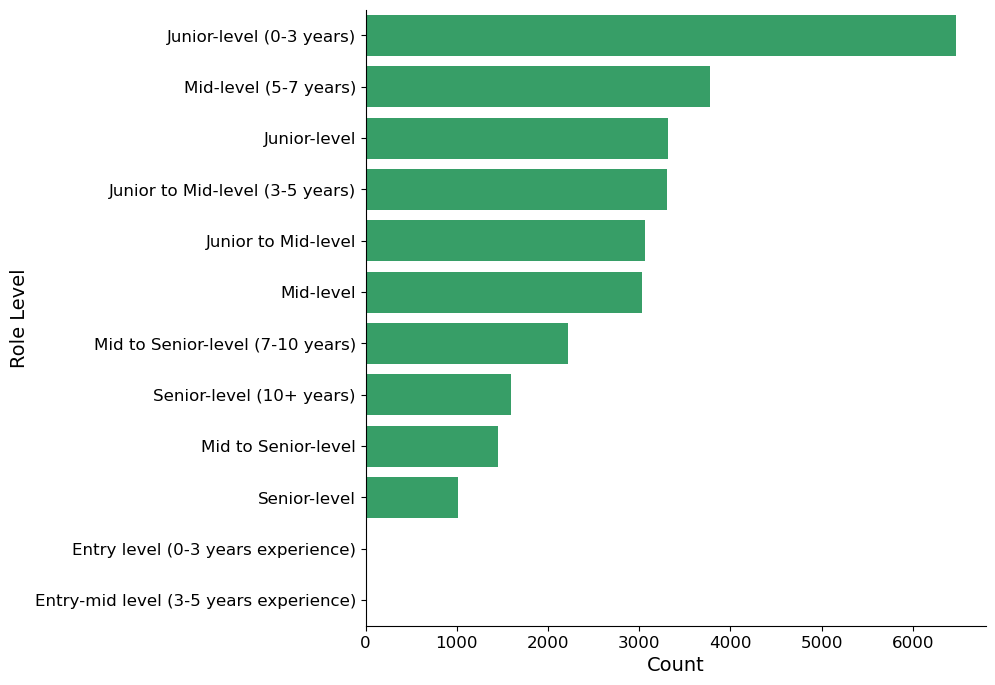

In [21]:
# visualization
role_class_dist = aff['role_level'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='role_level', order=role_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Role Level", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../outputs/visualizations/raw_data/role_levels_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Final Thoughts

### Take Aways
- Both NLP and categorical data must be cleaned before use in any classification model

    - This cleaning can be found in 'notebooks/clean_aff_data.ipynb' or 'scripts/clean_aff_data.py'

- Title is a suitable substitue for job role in instances where it's missing

### Recommendations
- Changes to resolve redundant and unused classes should be propegated through the database

- Mising job roles should be imputed with available job titles

- While role is a suitable as a free-response field, title may more appropriately be limited to a finite number of classes.  Doing so would allow for more fine grained analtics within different job functions and help differenciate carreers futhure. 